## Making the File 12 GB

In [1]:
with open('leipzig1GB.txt', 'r') as f:
    content = f.read()

with open('leipzig1GB.txt', 'w') as f:
    while f.tell() < 12 * 1024 * 1024 * 1024:  # 12 GB
        f.write(content)


# Necesary Imports

In [2]:
import pyspark
import os
import findspark
from pyspark.sql import SparkSession
from pyspark.conf import SparkConf
import matplotlib.pyplot as plt
import re




In [3]:
spark=SparkSession.builder.appName("211805033_YUSUSERTKAYAlarge12GB").getOrCreate()
spac = spark.sparkContext

24/11/30 23:47:35 WARN Utils: Your hostname, Yusuf-MacBook-Air.local resolves to a loopback address: 127.0.0.1; using 192.168.1.103 instead (on interface en0)
24/11/30 23:47:35 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/11/30 23:47:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
24/11/30 23:47:36 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


# Function to expand contractions



In [4]:
def clean_and_expand(text):
    # Expand contractions and remove unwanted characters
    text = re.sub(r"(isn't|Isn't)", "is not", text)
    text = re.sub(r"[!\"#\$%&'\(\)\*\+,\-./:;<=>\?@\[\]^_`{|}~0-9]", "", text)
    return text.lower()

# Clean data:


In [6]:
# Load and clean data
input_file = './leipzig1GB.txt'
rawDataRDD = spac.textFile(input_file)
cleanedLinesRDD = rawDataRDD.map(clean_and_expand).filter(lambda line: len(line.strip()) > 0)


In [7]:
# Word count
wordsRDD = cleanedLinesRDD.flatMap(lambda line: line.split()).filter(lambda word: len(word.strip()) > 0)
wordPairsRDD = wordsRDD.map(lambda word: (word, 1))
wordCounts = wordPairsRDD.reduceByKey(lambda x, y: x + y)

In [8]:
#sortedWordCounts = wordCounts.sortBy(lambda x: x[1], ascending=False) #this way was not efficent
top10Words = wordCounts.top(10, key=lambda x: x[1])# I need top 10 words so this way is better


In [24]:
# writing and processing the file
with open("first_ten_words.txt", 'w') as f:
    for word , count in top10Words:
        f.write(f'{word}\t{count}\n')

In [26]:

print("WORD\t--\tCOUNT")
print("---------------------------------------------")
for word, count in top10Words:
    print(f"{word}\t\t{count}")

WORD	--	COUNT
---------------------------------------------
- the		219242080
- of		95333600
- to		90607680
- a		81242880
- in		75770720
- and		71755040
- said		34543520
- for		34361440
- that		32322720
- is		28868480


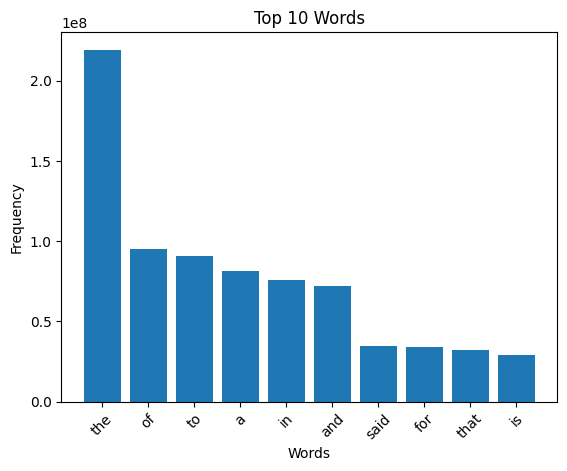

In [25]:
# Visualization
words, counts = zip(*top10Words)
plt.bar(words, counts)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 10 Words")
plt.xticks(rotation=45)
plt.show()


In [27]:
# Stop Spark
spac.stop()